<h2  align='center'>Face Verification System - Same Person or Not</h2>

**In this notebook we will use a pre-trained FaceNet model from TensorFlow Hub to verify if two face images are of the same person or not.**

In [1]:
import numpy as np
import cv2
import PIL.Image as Image
import matplotlib.pyplot as plt
import itertools
import os
import pandas as pd
from sklearn.metrics import accuracy_score
from keras_facenet import FaceNet
from mtcnn import MTCNN
import warnings  
warnings.filterwarnings('ignore')

In [2]:
# Load FaceNet model 
facenet_model = FaceNet()

In [3]:
# Load face detector 
detector = MTCNN()

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\moust\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\moust\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\moust\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


In [4]:
# Loading  two images 
image1_path = "..\\img\\img1.jpeg" 
image2_path = "..\\img\\img2.jpeg"  

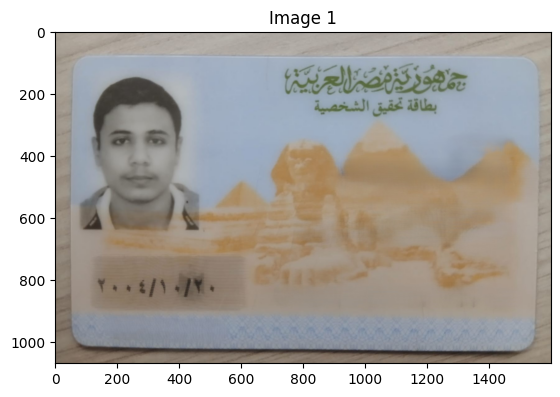

In [5]:
# Read first image
img1 = cv2.imread(image1_path)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(img1_rgb)
plt.title("Image 1")
plt.show()

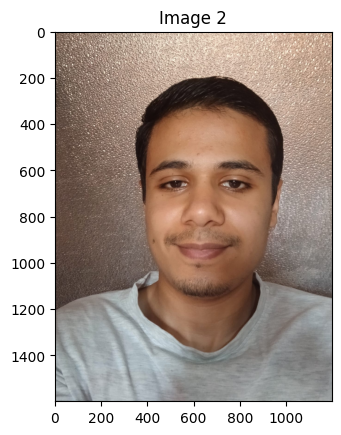

In [6]:
# Read second image
img2 = cv2.imread(image2_path)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img2_rgb)
plt.title("Image 2")
plt.show()

In [7]:
# Detect face in image 1
detections1 = detector.detect_faces(img1_rgb)
print(f"Number of faces detected in image 1: {len(detections1)}")

Number of faces detected in image 1: 1


In [8]:
# Get the bounding box of the face
x1, y1, w1, h1 = detections1[0]['box']

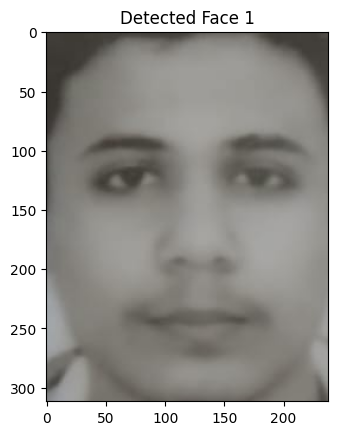

In [9]:
# Crop the face from image 1
face1 = img1_rgb[y1:y1+h1, x1:x1+w1]
plt.imshow(face1)
plt.title("Detected Face 1")
plt.show()


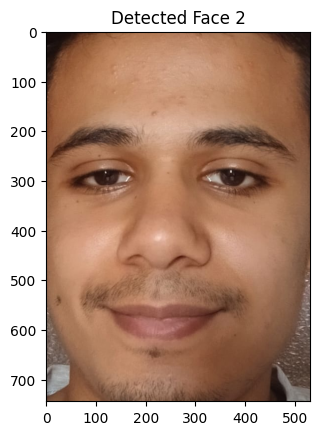

In [10]:
# Detect face in image 2
detections2 = detector.detect_faces(img2_rgb)
x2, y2, w2, h2 = detections2[0]['box']
face2 = img2_rgb[y2:y2+h2, x2:x2+w2]

plt.imshow(face2)
plt.title("Detected Face 2")
plt.show()

In [11]:
def face_resize (face, size=(160, 160)):
    return cv2.resize(face, size)

# Resize faces
face1_resized = face_resize(face1)
face2_resized = face_resize(face2)

# Check shapes
print(face1_resized.shape)
print(face2_resized.shape)

(160, 160, 3)
(160, 160, 3)


In [12]:
def add_batch (face):
    return np.expand_dims(face, axis=0)

# Add Batch Dimension
face1_batch = add_batch(face1_resized)
face2_batch = add_batch(face2_resized)

# Check shapes
print(face1_batch.shape)
print(face2_batch.shape)

(1, 160, 160, 3)
(1, 160, 160, 3)


In [13]:
def embedding (face):
    return facenet_model.embeddings(face)[0]

embedding1 = embedding(face1_batch)
embedding2 = embedding(face2_batch)

print(embedding1.shape)
print(embedding2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
(512,)
(512,)


In [14]:
# Look at first 10 values of embedding 1
embedding1[:10]

array([ 0.01897635,  0.07567962,  0.00679348,  0.01630395,  0.07217621,
        0.02438366,  0.02886914,  0.02529213, -0.05784512,  0.02410258],
      dtype=float32)

In [15]:
# Calculate Euclidean distance between the two embeddings
distance = np.linalg.norm(embedding1 - embedding2)
print(f"Distance between faces: {distance:.4f}")

Distance between faces: 0.5993


In [16]:
# Set threshold
threshold = 0.85

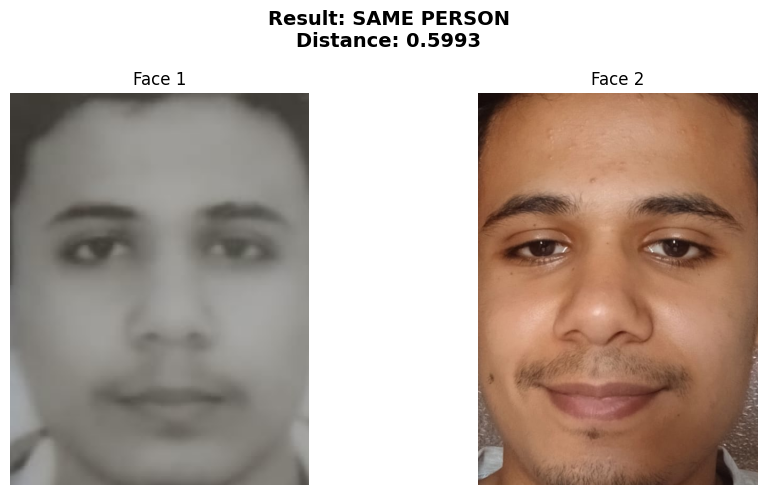

In [17]:
# Visualize result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(face1)
axes[0].set_title("Face 1")
axes[0].axis('off')
axes[1].imshow(face2)
axes[1].set_title("Face 2")
axes[1].axis('off')

result = "SAME PERSON" if distance < threshold else "DIFFERENT PERSON"
fig.suptitle(f"Result: {result}\nDistance: {distance:.4f}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h3 >Step 10: Create a reusable function that compares all faces between 2 images</h3>

In [18]:
#  Compare all faces between 2 images
def verify_all_faces(image1_path, image2_path, threshold=0.8):
    img1 = cv2.imread(image1_path)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.imread(image2_path)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    detections1 = detector.detect_faces(img1)
    detections2 = detector.detect_faces(img2)

    results = []

    for i, det1 in enumerate(detections1):
        x1, y1, w1, h1 = det1['box']
        face1 = img1[y1:y1+h1, x1:x1+w1]
        face1_resized = cv2.resize(face1, (160,160))
        face1_resized = np.expand_dims(face1_resized, axis=0)
        embedding1 = facenet_model.embeddings(face1_resized)[0]

        for j, det2 in enumerate(detections2):

            x2, y2, w2, h2 = det2['box']
            face2 = img2[y2:y2+h2, x2:x2+w2]
            face2_resized = cv2.resize(face2, (160,160))
            face2_resized = np.expand_dims(face2_resized, axis=0)
            embedding2 = facenet_model.embeddings(face2_resized)[0]
            distance = np.linalg.norm(embedding1 - embedding2)
            verified = distance < threshold

            results.append({
                'img1': img1,
                'img2': img2,
                'box1': (x1, y1, w1, h1),
                'box2': (x2, y2, w2, h2),
                'face1_index': i,
                'face2_index': j,
                'distance': distance,
                'verified': verified
            })

    return results

In [19]:
# Show matches on original images
def visualize_face_matches(results):

    for result in results:
        img1 = result['img1'].copy()
        img2 = result['img2'].copy()
        x1, y1, w1, h1 = result['box1']
        x2, y2, w2, h2 = result['box2']

        if result['verified']:
            color = (0,255,0)
            title = "MATCH"
        else:
            color = (255,0,0)
            title = "NOT MATCH"
        # Draw rectangles
        cv2.rectangle(img1, (x1,y1), (x1+w1,y1+h1), color, 2)
        cv2.rectangle(img2, (x2,y2), (x2+w2,y2+h2), color, 2)

        fig, axes = plt.subplots(1,2, figsize=(12,6))

        axes[0].imshow(img1)
        axes[0].set_title("Image 1")
        axes[0].axis('off')
        axes[1].imshow(img2)
        axes[1].set_title("Image 2")
        axes[1].axis('off')
        fig.suptitle(
            title + "  Distance: " + str(round(result['distance'],4)),
            fontsize=16,
            fontweight='bold',
            color='green' if result['verified'] else 'red'
        )

        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


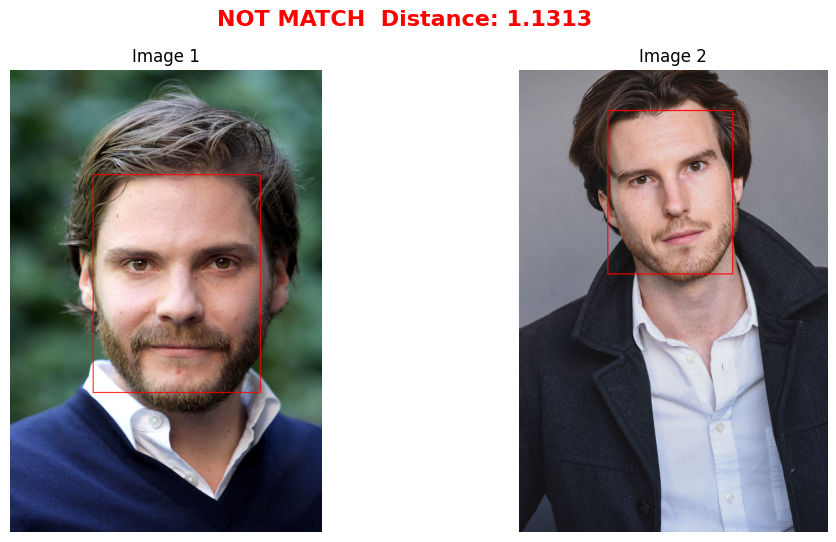

In [20]:
matches = verify_all_faces("..\\img\\img3.jpeg", "..\\img\\img4.jpeg")
visualize_face_matches(matches)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


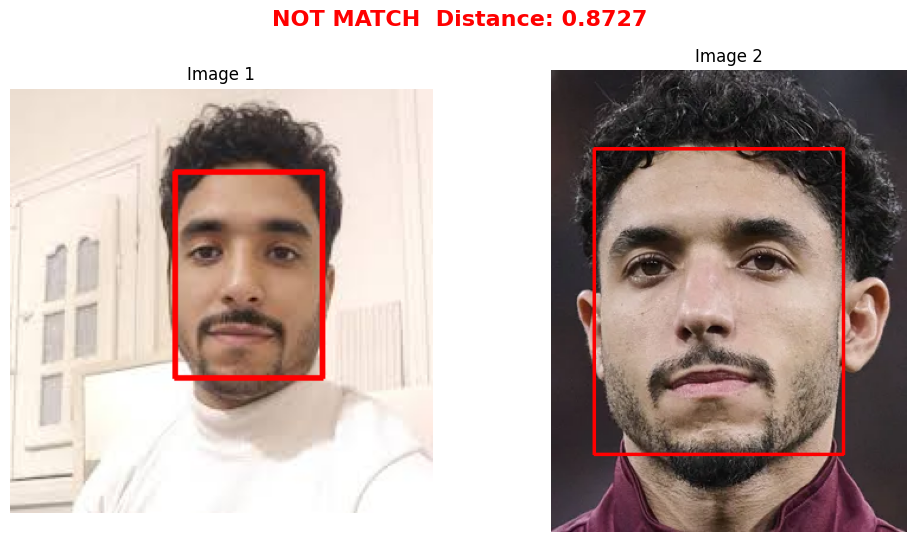

In [21]:
matches = verify_all_faces("..\\img\\img5.jpeg", "..\\img\\img6.jpeg")
visualize_face_matches(matches)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


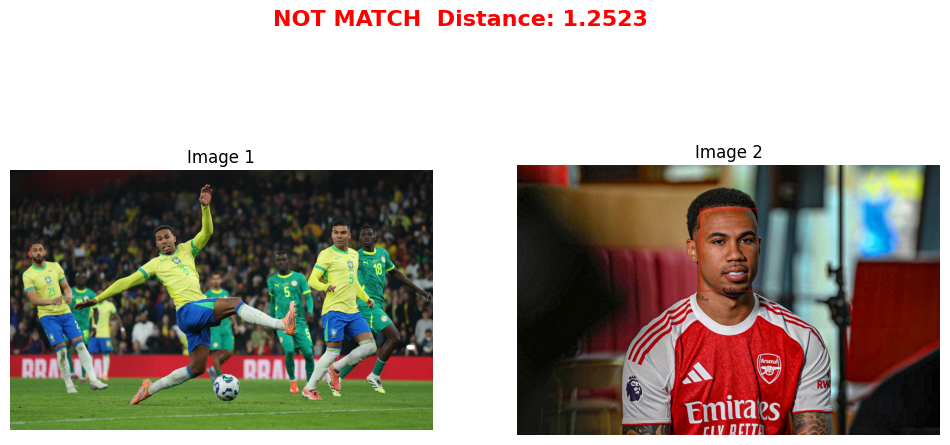

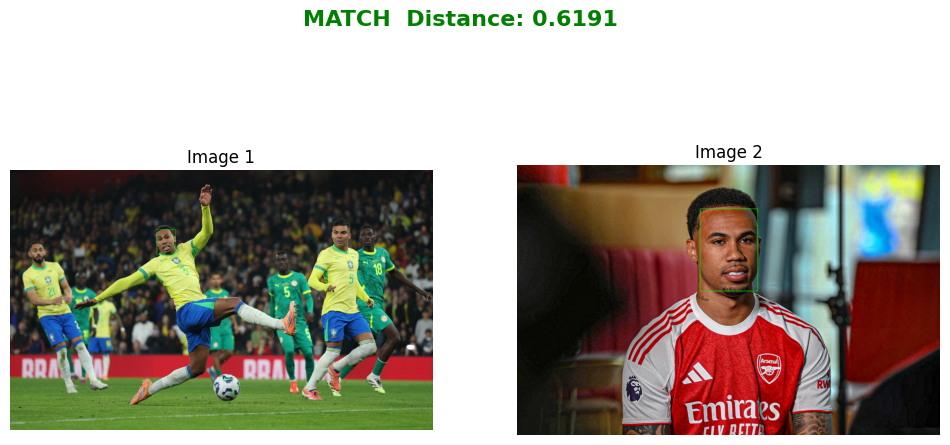

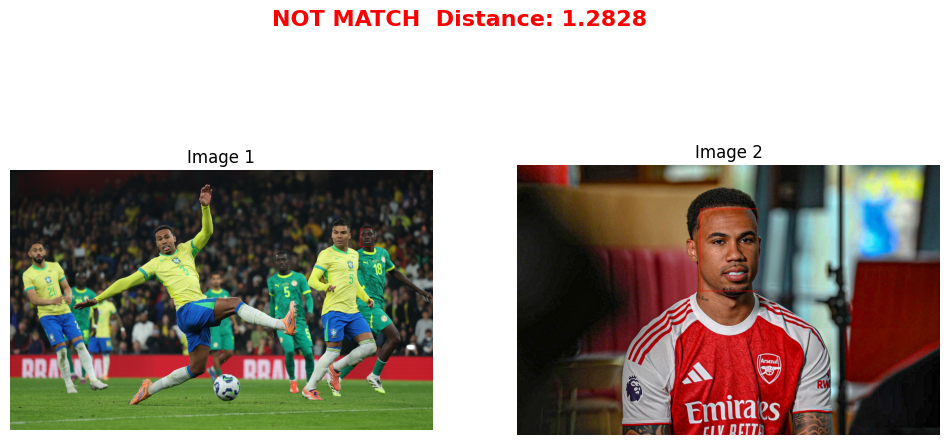

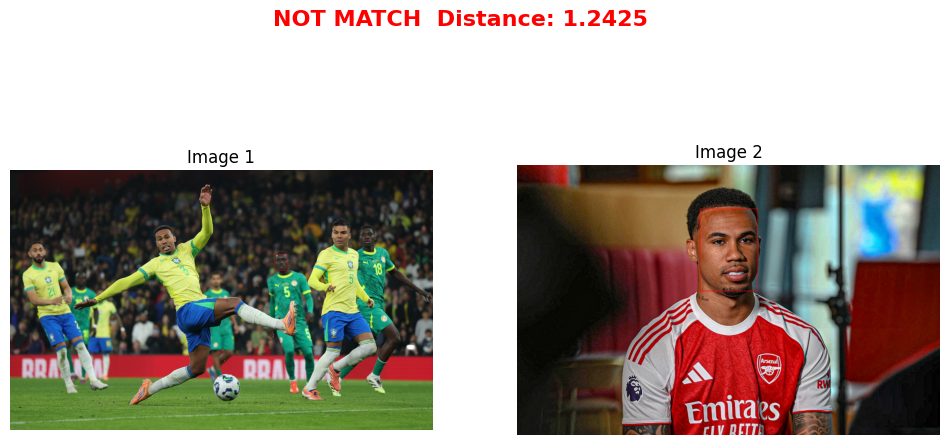

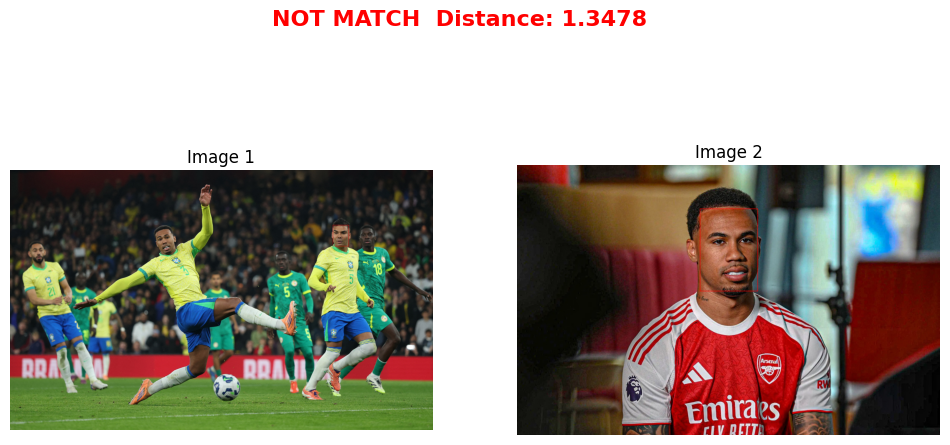

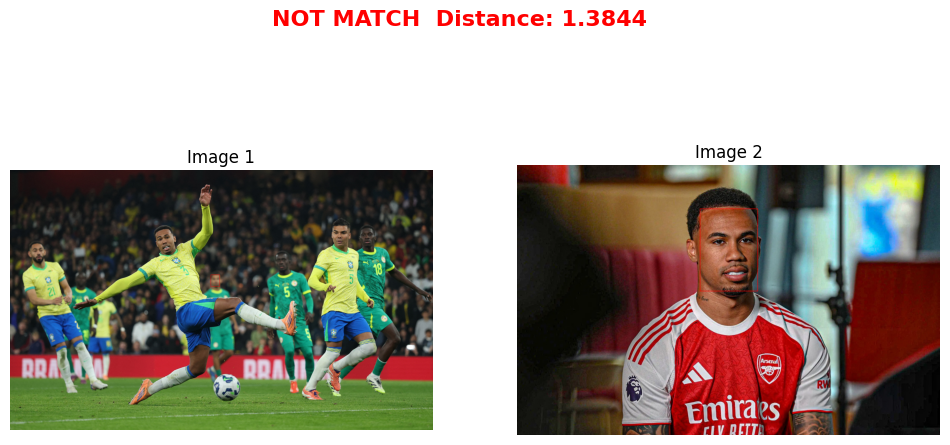

In [22]:
matches = verify_all_faces("..\\img\\img7.jpeg", "..\\img\\img8.jpeg")
visualize_face_matches(matches)

In [23]:
LFW_DIR = r"..\img\lfw\lfw-deepfunneled\lfw-deepfunneled"
MATCH_CSV = r"..\img\lfw\matchpairsDevTest.csv"
MISMATCH_CSV = r"..\img\lfw\mismatchpairsDevTest.csv"
THRESHOLD = 0.85

In [24]:
def get_image_path(name, imagenum):
    filename = f"{name}_{int(imagenum):04d}.jpg"
    return os.path.join(LFW_DIR, name, filename)

In [25]:
def verify_pair(path1, path2, threshold=THRESHOLD):
    img1 = cv2.imread(path1)
    img2 = cv2.imread(path2)
    if img1 is None or img2 is None:
        return None
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    det1 = detector.detect_faces(img1)
    det2 = detector.detect_faces(img2)
    if not det1 or not det2:
        return None
    x1,y1,w1,h1 = det1[0]['box']
    x2,y2,w2,h2 = det2[0]['box']
    face1 = cv2.resize(img1[y1:y1+h1, x1:x1+w1], (160,160))
    face2 = cv2.resize(img2[y2:y2+h2, x2:x2+w2], (160,160))
    emb1 = facenet_model.embeddings(np.expand_dims(face1, axis=0))[0]
    emb2 = facenet_model.embeddings(np.expand_dims(face2, axis=0))[0]
    distance = np.linalg.norm(emb1 - emb2)
    return distance < threshold


In [26]:
match_df = pd.read_csv(MATCH_CSV)
mismatch_df = pd.read_csv(MISMATCH_CSV)

y_true = []
y_pred = []
skipped = 0


In [27]:
for _, row in match_df.iterrows():
    p1 = get_image_path(row['name'], row['imagenum1'])
    p2 = get_image_path(row['name'], row['imagenum2'])
    result = verify_pair(p1, p2)
    if result is None:
        skipped += 1
        continue
    y_true.append(1)
    y_pred.append(int(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━

In [28]:
for _, row in mismatch_df.iterrows():
    cols = mismatch_df.columns
    p1 = get_image_path(row[cols[0]], row[cols[1]])
    p2 = get_image_path(row[cols[2]], row[cols[3]])
    result = verify_pair(p1, p2)
    if result is None:
        skipped += 1
        continue
    y_true.append(0)
    y_pred.append(int(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

In [29]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)

In [30]:
diff_mask = y_true == 0
FAR = y_pred[diff_mask].sum() / diff_mask.sum()


same_mask = y_true == 1
FRR = (1 - y_pred[same_mask]).sum() / same_mask.sum()

print(f"Pairs evaluated : {len(y_true)}  |  Skipped: {skipped}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"FAR             : {FAR:.4f}  (false accepts — different people matched)")
print(f"FRR             : {FRR:.4f}  (false rejects — same person not matched)")

Pairs evaluated : 1000  |  Skipped: 0
Accuracy        : 0.9070
FAR             : 0.0000  (false accepts — different people matched)
FRR             : 0.1860  (false rejects — same person not matched)
